# Transformer Image Captioning — Google Colab

This notebook runs on **Google Colab with a GPU runtime** and covers:
1. Mount Google Drive and set up the project
2. Install dependencies
3. Extract ResNet-50 spatial features
4. Train the Transformer decoder
5. Evaluate BLEU / METEOR on the validation split

---
### Before running
1. **Runtime → Change runtime type → T4 GPU**
2. Ensure your project folder is on Google Drive:
   ```
   MyDrive/
   └── deeplearning-project/
       ├── data/Images/
       ├── metadata/
       ├── src/
       ├── scripts/
       └── notebooks/
   ```

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys

# ---- Edit this if your folder is in a subfolder of MyDrive ----
PROJECT_ROOT = "/content/drive/MyDrive/deeplearning-project"
# ---------------------------------------------------------------

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Working directory:", os.getcwd())
print("Contents:", os.listdir("."))

Working directory: /content/drive/MyDrive/deeplearning-project
Contents: ['notebooks', 'README.md', '.gitignore', 'requirements.txt', 'tests', 'scripts', 'src', 'metadata', 'data', 'configs', '.github', '.git', 'checkpoints', 'Untitled0.ipynb']


## 2. Install Dependencies

In [3]:
!pip install -q nltk

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import torch
import torchvision
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"GPU         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE — change runtime to GPU'}")

torch       : 2.10.0+cu128
torchvision : 0.25.0+cu128
GPU         : Tesla T4


## 3. Configuration

In [4]:
from pathlib import Path

# --- Paths ---
CAPTIONS_PATH  = Path("data/captions.txt")
IMAGES_DIR     = Path("data/Images")
FEATURES_DIR   = Path("data/transformer_features")
VOCAB_PATH     = Path("metadata/vocab/flickr30k_vocab.json")
SPLITS_DIR     = Path("metadata/splits")
CHECKPOINT_DIR = Path("checkpoints/transformer")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# --- Feature dimensions ---
NUM_PATCHES  = 49
FEATURE_DIM  = 2048

# --- Transformer hyperparameters (configurable) ---
EMBED_DIM  = 512
NUM_HEADS  = 8
NUM_LAYERS = 3
FF_DIM     = 2048
DROPOUT    = 0.1

# --- Training hyperparameters ---
BATCH_SIZE  = 32
LR          = 1e-4
GRAD_CLIP   = 1.0
NUM_EPOCHS  = 20
LR_STEP     = 5
LR_GAMMA    = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 4. Feature Extraction

Extracts 7×7 = 49 spatial features (2048-dim each) per image using ResNet-50.

**Expected time: ~2–3 hrs on T4 GPU for full Flickr30k.**

ResNet-50 extraction is much faster than Faster R-CNN because it just does
a single forward pass with no region proposals.

In [ ]:
from src.data.splits import load_split_file

train_ids = load_split_file(SPLITS_DIR / "train.txt")
val_ids   = load_split_file(SPLITS_DIR / "val.txt")
test_ids  = load_split_file(SPLITS_DIR / "test.txt")
all_ids   = train_ids + val_ids + test_ids

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
missing = [iid for iid in all_ids if not (FEATURES_DIR / f"{iid}.pt").exists()]
print(f"Images total   : {len(all_ids)}")
print(f"Features ready : {len(all_ids) - len(missing)}")
print(f"Missing        : {len(missing)}")

Images total   : 31783
Features ready : 0
Missing        : 31783


In [ ]:
# Copy images to local SSD to avoid Drive I/O bottleneck during extraction. It can take upto 3hr on GPU
import shutil, os
from tqdm import tqdm

LOCAL_IMAGES = "/content/Images"
os.makedirs(LOCAL_IMAGES, exist_ok=True)

image_files = os.listdir(str(IMAGES_DIR))
print(f"Copying {len(image_files)} images...")

for fname in tqdm(image_files, unit="img"):
    src = IMAGES_DIR / fname
    dst = LOCAL_IMAGES + "/" + fname
    if not os.path.exists(dst):
        shutil.copy2(str(src), dst)

print("Done.")


Copying 31786 images...


100%|██████████| 31786/31786 [00:00<00:00, 90051.12img/s]

Done.


In [ ]:
# Confirm feature extraction from drive to local SSD.

LOCAL_IMAGES = "/content/Images"
if missing and not os.path.exists(LOCAL_IMAGES):
    print("Copying images to local storage …")
    shutil.copytree(str(IMAGES_DIR), LOCAL_IMAGES)
    print("Done.")
elif os.path.exists(LOCAL_IMAGES):
    print("Local images already present.")
else:
    print("All features already extracted — no image copy needed.")

In [ ]:
#perform the feature extraction. Takes less than 1hr on GPU. 
if missing:
    print("Starting feature extraction …")
    !python scripts/extract_transformer_features.py \
        --images-dir  /content/Images \
        --output-dir  data/transformer_features \
        --splits-dir  metadata/splits \
        --batch-size  64 \
        --device      cuda
else:
    print("All features already extracted — skipping.")

Starting feature extraction …
Device: cuda
Total images: 31783, already done: 17408, to extract: 14375
Loading pretrained ResNet-50 …
Model loaded.
  [100/225]  44.4%  saved 6399 features
  [200/225]  88.9%  saved 12799 features
  [225/225]  100.0%  saved 14374 features

Done. Saved 14374 feature files to /content/drive/MyDrive/deeplearning-project/data/transformer_features


In [ ]:
sample_feat = torch.load(FEATURES_DIR / f"{all_ids[0]}.pt", weights_only=True)
print(f"Feature shape        : {sample_feat.shape}")  # (49, 2048)
print(f"dtype                : {sample_feat.dtype}")
print(f"Total .pt files now  : {len(list(FEATURES_DIR.glob('*.pt')))}")  # ~31k

Feature shape        : torch.Size([49, 2048])
dtype                : torch.float32
Total .pt files now  : 31782


## 5. Dataset and DataLoaders

In [20]:
import shutil, os
from pathlib import Path

LOCAL_FEATURES = "/content/transformer_features"
if not os.path.exists(LOCAL_FEATURES):
    print("Copying transformer features to local SSD…")
    shutil.copytree(str(FEATURES_DIR), LOCAL_FEATURES)
    print("Done.")
else:
    print("Local features already present.")

LOCAL_FEATURES_DIR = Path(LOCAL_FEATURES)


Copying transformer features to local SSD…
Done.


In [21]:
from src.data.vocab import Vocabulary
from src.data.splits import load_caption_map
from src.data.transformer_dataset import create_transformer_dataloader

vocab = Vocabulary.load(VOCAB_PATH)
vocab_size = len(vocab.word2idx)
print(f"Vocabulary size : {vocab_size}")

caption_map = load_caption_map(CAPTIONS_PATH)

train_loader = create_transformer_dataloader(
    caption_map=caption_map,
    features_dir=LOCAL_FEATURES_DIR,
    split_image_ids=train_ids,
    vocab=vocab,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

val_loader = create_transformer_dataloader(
    caption_map=caption_map,
    features_dir=LOCAL_FEATURES_DIR,
    split_image_ids=val_ids,
    vocab=vocab,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} samples)")
print(f"Val batches   : {len(val_loader)}  ({len(val_loader.dataset)} samples)")

Vocabulary size : 7013
[TransformerCaptionDataset] 1/25426 images have no feature file and were skipped. Run scripts/extract_transformer_features.py to generate missing features.
Train batches : 3973  (127125 samples)
Val batches   : 497  (15890 samples)


In [22]:
sample_batch = next(iter(train_loader))
print("features     :", sample_batch["features"].shape)    # (B, 49, 2048)
print("caption_ids  :", sample_batch["caption_ids"].shape)
print("Sample caption:", sample_batch["caption_texts"][0])

features     : torch.Size([32, 49, 2048])
caption_ids  : torch.Size([32, 23])
Sample caption: Three men are on the patio of an apartment in a crowded city .


## 6. Model

In [23]:
from src.models.transformer_model import TransformerCaptionModel

model = TransformerCaptionModel(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    ff_dim=FF_DIM,
    feature_dim=FEATURE_DIM,
    dropout=DROPOUT,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"Config: {NUM_LAYERS} layers, {NUM_HEADS} heads, embed_dim={EMBED_DIM}")

Trainable parameters: 20,851,557
Config: 3 layers, 8 heads, embed_dim=512


In [24]:
model.eval()
with torch.no_grad():
    test_feats = sample_batch["features"][:2].to(device)
    test_caps  = sample_batch["caption_ids"][:2].to(device)
    logits = model(test_feats, test_caps)
    print(f"Logits shape : {logits.shape}  — expected (2, T, {vocab_size})")
    gen = model.generate(test_feats, vocab.word2idx["<start>"], vocab.word2idx["<end>"])
    print(f"Generated    : {' '.join(vocab.decode(gen[0].tolist()))}")
model.train();

Logits shape : torch.Size([2, 23, 7013])  — expected (2, T, 7013)
Generated    : bumpy passage bumpy award wetsuit wetsuit passage kites plain farmer wetsuit wetsuit wetsuit wade wade wade wetsuit wetsuit wade want wade wade wade wade straddling kites details short-sleeve short-sleeve fist fist sink write brooms fist fist approaching write brooms fist


## 7. Training

Expect training to last up to 2hrs on GPU

In [25]:
import torch.nn as nn
import torch.optim as optim
from src.training.train_transformer import train_one_epoch, evaluate_loss

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

train_losses = []
val_losses   = []
best_val_loss = float("inf")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, GRAD_CLIP)
    val_loss   = evaluate_loss(model, val_loader, criterion, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    flag = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "hparams": {
                    "vocab_size": vocab_size,
                    "embed_dim": EMBED_DIM,
                    "num_heads": NUM_HEADS,
                    "num_layers": NUM_LAYERS,
                    "ff_dim": FF_DIM,
                    "feature_dim": FEATURE_DIM,
                },
            },
            CHECKPOINT_DIR / "best.pt",
        )
        flag = "  ← best"

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS}  "
        f"train={train_loss:.4f}  "
        f"val={val_loss:.4f}{flag}"
    )

Epoch 01/20  train=3.0979  val=2.6653  ← best


Epoch 02/20  train=2.4974  val=2.4966  ← best


Epoch 03/20  train=2.2778  val=2.4445  ← best


Epoch 04/20  train=2.1168  val=2.4451


Epoch 05/20  train=1.9826  val=2.4572


...

Epoch 16/20  train=1.2053  val=2.8380


Epoch 17/20  train=1.1855  val=2.8609


Epoch 18/20  train=1.1694  val=2.8784


Epoch 19/20  train=1.1534  val=2.8961


Epoch 20/20  train=1.1379  val=2.9180


## 8. Loss Curves

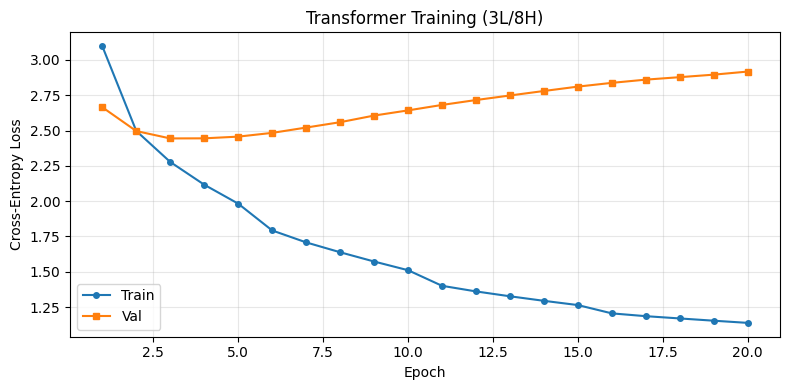

Best val loss : 2.4445


In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
epochs = range(1, len(train_losses) + 1)
ax.plot(epochs, train_losses, label="Train", marker="o", markersize=4)
ax.plot(epochs, val_losses,   label="Val",   marker="s", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title(f"Transformer Training ({NUM_LAYERS}L/{NUM_HEADS}H)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("notebooks/transformer_loss_curve.png", dpi=120)
plt.show()
print(f"Best val loss : {best_val_loss:.4f}")

## 9. Evaluation (BLEU / METEOR)

In [27]:
from src.training.train_transformer import generate_captions
from src.eval.metrics import evaluate_captions

checkpoint = torch.load(CHECKPOINT_DIR / "best.pt", map_location=device, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded epoch {checkpoint['epoch']}  (val_loss={checkpoint['val_loss']:.4f})")

print("Generating captions …")
val_predictions = generate_captions(model, val_loader, vocab, device)
print(f"Generated {len(val_predictions)} captions")

val_references = {iid: caption_map[iid] for iid in val_predictions if iid in caption_map}
scores = evaluate_captions(val_references, val_predictions, require_exact_match=False)

print("\n=== Validation Scores ===")
for metric, score in scores.items():
    print(f"  {metric.upper():8s}: {score:.4f}")

Loaded epoch 3  (val_loss=2.4445)
Generating captions …
Generated 3178 captions

=== Validation Scores ===
  BLEU_1  : 0.6686
  BLEU_2  : 0.4611
  BLEU_3  : 0.3183
  BLEU_4  : 0.2216
  METEOR  : 0.4230


## 10. Sample Predictions

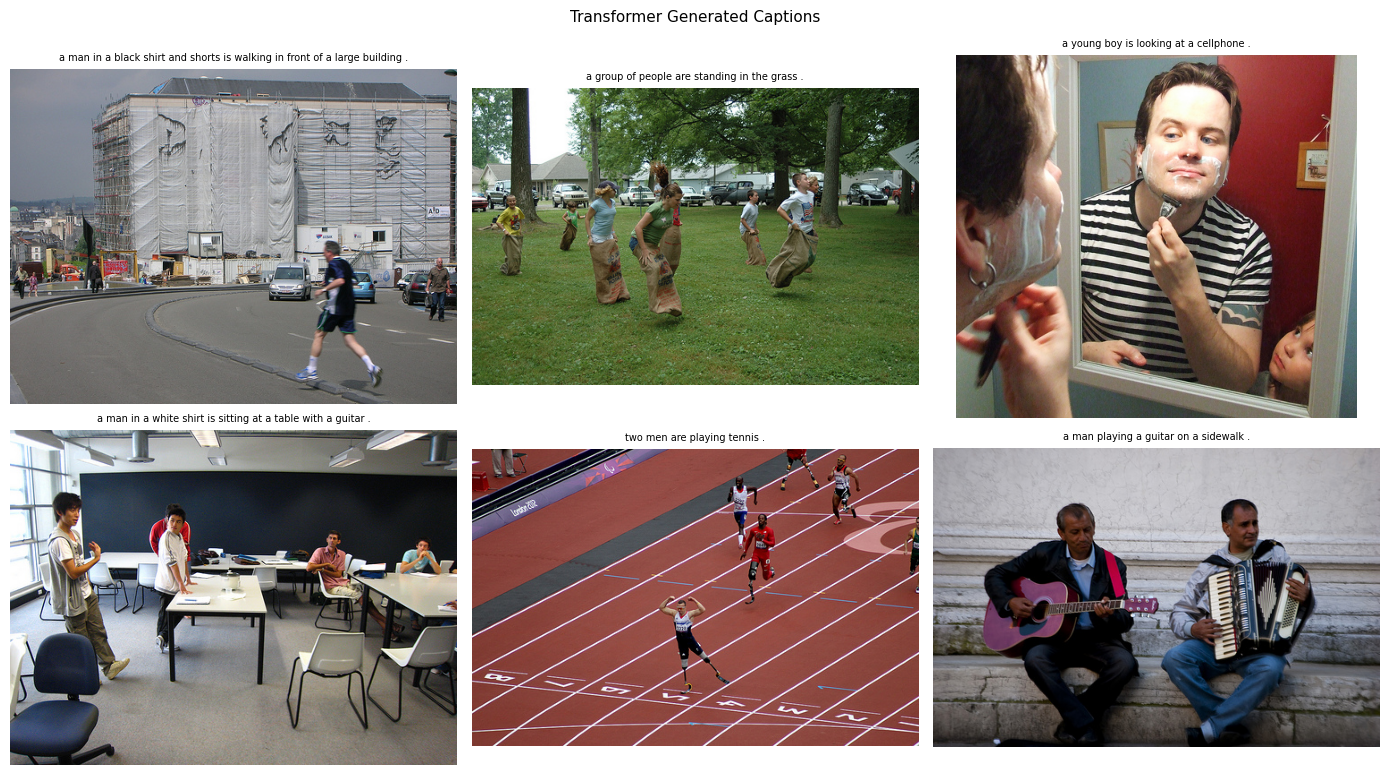

In [28]:
import random
from PIL import Image

sample_ids = random.sample(sorted(val_predictions.keys()), min(6, len(val_predictions)))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, iid in zip(axes.flatten(), sample_ids):
    img_path = IMAGES_DIR / iid
    if img_path.exists():
        ax.imshow(Image.open(img_path).convert("RGB"))
    ax.axis("off")
    ax.set_title(val_predictions[iid], fontsize=7, wrap=True)
fig.suptitle("Transformer Generated Captions", fontsize=11)
fig.tight_layout()
plt.show()

In [29]:
for iid in sample_ids:
    print(f"Image : {iid}")
    print(f"  Generated : {val_predictions[iid]}")
    print("  References:")
    for ref in caption_map.get(iid, []):
        print(f"    - {ref}")
    print()

Image : 3534388678.jpg
  Generated : a man in a black shirt and shorts is walking in front of a large building .
  References:
    - A man running across the street in front of a building under construction .
    - A man jogs down the street in front of a building under construction .
    - man jogging on a road , in front of a big unfinished building .
    - A man in blue running across the street and avoiding traffic .
    - An elderly man goes for a run on a busy street .

Image : 202436011.jpg
  Generated : a group of people are standing in the grass .
  References:
    - Six children are wearing burlap sacks and having a potato sack race .
    - Boys and girls of various ages participate in a potato sack race .
    - Young children have fun while playing sack jumping in park .
    - People jumping in sacks in a grassy area with trees .
    - Many kids are participating in a potato sack race .

Image : 2384754746.jpg
  Generated : a young boy is looking at a cellphone .
  Reference

## 11. Save Outputs to Drive

In [30]:
import json

pred_path = Path("configs/transformer_val_predictions.json")
with pred_path.open("w") as fh:
    json.dump(val_predictions, fh, indent=2)

checks = {
    "Best checkpoint"       : CHECKPOINT_DIR / "best.pt",
    "Predictions JSON"      : pred_path,
    "Loss curve image"      : Path("notebooks/transformer_loss_curve.png"),
    "Feature files (count)" : FEATURES_DIR,
}
for label, path in checks.items():
    if path.is_dir():
        print(f"  {label:25s}: {len(list(path.glob('*.pt')))} files")
    else:
        print(f"  {label:25s}: {'OK' if path.exists() else 'MISSING'}  ({path})")

  Best checkpoint          : OK  (checkpoints/transformer/best.pt)
  Predictions JSON         : OK  (configs/transformer_val_predictions.json)
  Loss curve image         : OK  (notebooks/transformer_loss_curve.png)
  Feature files (count)    : 31782 files
